In [3]:
"""
FASE 1: Clasificación de géneros literarios
Notebook 01: Análisis Exploratorio de Datos (EDA)

Objetivo: 
-Entender los datos
-Identificar problemas (nulos, duplicados)
-Visualizar distribuciones
-Decidir estrategia de limpieza

"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

print("Setup completado")

Setup completado


In [4]:
df = pd.read_csv('../../data/raw/books.csv')

print("Dataset cargado")

Dataset cargado


In [6]:
"Consultar número de filas y columnas"
df.shape

(6810, 12)

In [7]:
"Ver primeras filas"
df.head()

,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0
2,9780006163831,0006163831,The One Tree,NaN,Stephen R. Donaldson,American fiction,http://books.google.com/books/content?id=OmQaw...,Volume Two of Stephen Donaldson's acclaimed se...,1982.0,3.97,479.0,172.0
3,9780006178736,0006178731,Rage of angels,NaN,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0
4,9780006280897,0006280897,The Four Loves,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0


In [8]:
"Info general"
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6810 entries, 0 to 6809
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   isbn13          6810 non-null   int64  
 1   isbn10          6810 non-null   object 
 2   title           6810 non-null   object 
 3   subtitle        2381 non-null   object 
 4   authors         6738 non-null   object 
 5   categories      6711 non-null   object 
 6   thumbnail       6481 non-null   object 
 7   description     6548 non-null   object 
 8   published_year  6804 non-null   float64
 9   average_rating  6767 non-null   float64
 10  num_pages       6767 non-null   float64
 11  ratings_count   6767 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 638.6+ KB


In [9]:
"Analizar nulos"
df.isnull().sum()

isbn13               0
isbn10               0
title                0
subtitle          4429
authors             72
categories          99
thumbnail          329
description        262
published_year       6
average_rating      43
num_pages           43
ratings_count       43
dtype: int64

In [11]:
"Contar apariciones de cada género"
df['categories'].value_counts()

categories
Fiction                                  2588
Juvenile Fiction                          538
Biography & Autobiography                 401
History                                   264
Literary Criticism                        166
                                         ... 
Authors, Cuban                              1
Death (Fictitious character : Gaiman)       1
Astronomers                                 1
Epic literature                             1
Girls                                       1
Name: count, Length: 567, dtype: int64

In [12]:
"Obtener top 10 géneros"
df['categories'].value_counts().head(10)

categories
Fiction                      2588
Juvenile Fiction              538
Biography & Autobiography     401
History                       264
Literary Criticism            166
Philosophy                    160
Comics & Graphic Novels       159
Religion                      137
Drama                         132
Juvenile Nonfiction           116
Name: count, dtype: int64

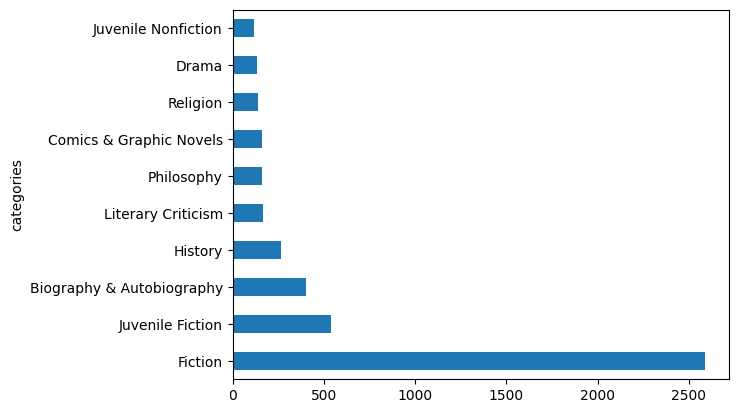

In [16]:
"Obtener un gráfico simple"
top_10 = df['categories'].value_counts().head(10)
top_10.plot(kind='barh')
plt.show()

In [18]:
df['authors'].value_counts().head(10)

authors
Agatha Christie              37
Stephen King                 36
William Shakespeare          35
John Ronald Reuel Tolkien    26
Virginia Woolf               23
Sandra Brown                 23
Orson Scott Card             21
Janet Evanovich              20
Piers Anthony                19
Terry Brooks                 17
Name: count, dtype: int64

In [20]:
df['ratings_count'].describe()

count    6.767000e+03
mean     2.106910e+04
std      1.376207e+05
min      0.000000e+00
25%      1.590000e+02
50%      1.018000e+03
75%      5.992500e+03
max      5.629932e+06
Name: ratings_count, dtype: float64

In [27]:
"Cuántos libros tienen un 0% de ratings"
libros_sin_ratings = (df['ratings_count'] == 0).sum()
print(f"Libros con 0 ratings: {libros_sin_ratings}")

Libros con 0 ratings: 27


In [30]:
"Cuántos géneros únicos"
generos_unicos = df['categories'].nunique()
print(f"Generos únicos: {generos_unicos}")

Generos únicos: 567


In [31]:
libros_sin_categoria = df['categories'].isnull().sum()
print(f"Libros sin  categoría: {libros_sin_categoria}")

Libros sin  categoría: 99


In [35]:
popular = df.nlargest(1, 'ratings_count')[['title', 'authors', 'ratings_count']]
print(f"Libro más popular: {popular}")

Libro más popular:                                                title        authors  \
2698  Harry Potter and the Sorcerer's Stone (Book 1)  Rowling, J.K.   

      ratings_count  
2698      5629932.0  
